# Introducción: Modelado Predictivo de Calidad del Aire

En esta tarea aplicaremos metodologías de **Aprendizaje Supervisado** para resolver dos problemas analíticos distintos basados en un conjunto de datos ambientales. Este dataset incluye mediciones sobre niveles de partículas (`pm25`), dióxido de nitrógeno (`no2`), volumen de `trafico` y velocidad del `viento`.

A partir de estas variables causales, el análisis se dividirá en dos grandes objetivos, cada uno con un tratamiento de datos específico:

### 1. Problema de Clasificación: Predicción de Alertas Ambientales
El primer objetivo es entrenar un modelo (ej. Regresión Logística) capaz de clasificar si las condiciones dadas activarán una **`alerta`** ambiental (True/False). 

* **Decisión Metodológica (Prevención de Fuga de Datos):** Para entrenar este modelo, utilizaremos estrictamente las variables ambientales y de tráfico como predictores (X). La variable continua `contaminacion` será intencionalmente **excluida**. Dado que una alerta se activa como consecuencia directa de cruzar un umbral de contaminación, incluir esta variable generaría una *Fuga de Datos (Data Leakage)*. El modelo simplemente aprendería la regla de activación en lugar de predecir la alerta basándose en sus causas reales, perdiendo toda su utilidad predictiva.

### 2. Problema de Regresión: Estimación del Índice de Contaminación
El segundo objetivo es construir un modelo (ej. Regresión Lineal Múltiple) que estime el valor numérico continuo de la **`contaminacion`**.

* **Decisión Metodológica (Definición del Target):** En este escenario, `contaminacion` asume el rol de nuestra variable objetivo (y), por lo que naturalmente sale de la matriz de características (X). Adicionalmente, la variable `alerta` también será descartada de los predictores para evitar un sesgo predictivo inverso, obligando al algoritmo a trazar la relación matemática pura entre los contaminantes base y el índice final.

---

### Flujo de Trabajo en los Siguientes Bloques de Código:
1. **Preprocesamiento:** Limpieza de valores nulos y escalado de las magnitudes numéricas para garantizar que los modelos converjan adecuadamente.
2. **Desarrollo del Clasificador:** Entrenamiento del modelo para predecir alertas, validando su rendimiento a través de la Exactitud, Precision, Recall y el análisis de la Matriz de Confusión.
3. **Desarrollo del Regresor:** Entrenamiento del modelo para estimar el nivel de contaminación, evaluando su precisión mediante métricas de error (RMSE, MAE) y varianza explicada (R2-score).

In [49]:
# Importar librerías
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [50]:
import sys
print(sys.executable)

/home/jonagu/Desktop/Cursos/IA/.venv_ia/bin/python


In [51]:
# Cargar datos desde CSV
datos = pd.read_csv('grupo4.csv')

In [52]:
datos


,pm25,no2,trafico,viento,contaminacion,alerta
0,73.61,31.07,38.60,4.24,114.43,False
1,47.44,22.29,66.58,3.18,166.47,False
2,63.47,60.26,46.17,4.02,153.76,False
3,56.78,40.42,80.38,5.57,157.88,False
4,56.62,47.95,57.15,4.34,152.36,False
...,...,...,...,...,...,...
495,8.36,42.94,81.49,3.77,91.82,False
496,49.73,46.21,64.14,0.55,164.94,True
497,40.84,46.61,29.05,1.33,127.15,False
498,47.82,37.03,36.70,3.81,139.99,False


In [53]:
# Dividir los datos en características (X) y variable objetivo (y)
X = datos.drop('contaminacion', axis=1)
y = datos['contaminacion']

In [54]:
X

,pm25,no2,trafico,viento,alerta
0,73.61,31.07,38.60,4.24,False
1,47.44,22.29,66.58,3.18,False
2,63.47,60.26,46.17,4.02,False
3,56.78,40.42,80.38,5.57,False
4,56.62,47.95,57.15,4.34,False
...,...,...,...,...,...
495,8.36,42.94,81.49,3.77,False
496,49.73,46.21,64.14,0.55,True
497,40.84,46.61,29.05,1.33,False
498,47.82,37.03,36.70,3.81,False


In [55]:
y

0      114.43
1      166.47
2      153.76
3      157.88
4      152.36
        ...  
495     91.82
496    164.94
497    127.15
498    139.99
499    110.00
Name: contaminacion, Length: 500, dtype: float64

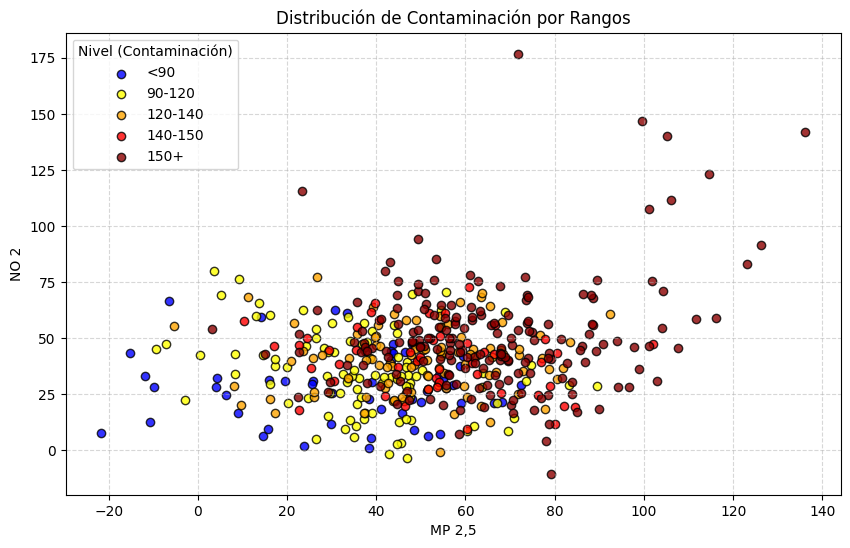

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Definimos los cortes y las etiquetas
# Los bins son: (-inf a 90], (90 a 120], (120 a 140], (140 a 150], (150 a inf)
# Nota: He ajustado los cortes para seguir tu lógica exacta.
bins = [0, 90, 120, 140, 150, float('inf')]
labels = ['<90', '90-120', '120-140', '140-150', '150+']
colores = ['blue', 'yellow', 'orange', 'red', 'darkred']

# 2. Creamos la columna de categorías basada en 'y'
datos['categoria'] = pd.cut(datos['contaminacion'], bins=bins, labels=labels)

# Crear la figura
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Graficamos por grupos para que la leyenda sea automática
for label, color in zip(labels, colores):
    indices = datos['categoria'] == label
    ax.scatter(datos.loc[indices, 'pm25'], 
               datos.loc[indices, 'no2'], 
               c=color, 
               label=label, 
               edgecolors='black', 
               alpha=0.8)

# Configuración de estética
ax.set_xlabel('MP 2,5')
ax.set_ylabel('NO 2')
ax.set_title('Distribución de Contaminación por Rangos')
ax.legend(title="Nivel (Contaminación)")
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [57]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Asegúrate de que X solo tiene variables numéricas y no tiene nulos
# (Si tienes nulos, usa X = X.dropna() antes de este paso)
datos = datos.dropna(subset=['pm25', 'no2', 'trafico', 'viento', 'alerta', 'contaminacion']).reset_index(drop=True)
X = datos[['pm25', 'no2', 'trafico', 'viento']] 

# 2. Inicializar el escalador
scaler = StandardScaler()

# 3. Ajustar y transformar los datos (esto devuelve un arreglo de NumPy)
X_scaled_array = scaler.fit_transform(X)

# 4. Volver a convertirlo en un DataFrame de Pandas para mantener los nombres de las columnas
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

# Ver los primeros resultados
display(X_scaled)

,pm25,no2,trafico,viento
0,0.915898,-0.501928,-0.977905,1.057183
1,-0.180161,-0.922290,0.120571,0.127778
2,0.491212,0.895606,-0.680712,0.864288
3,0.211019,-0.054277,0.662350,2.223324
4,0.204318,0.306238,-0.249644,1.144863
...,...,...,...,...
466,-1.816921,0.066373,0.705928,0.645088
467,-0.084251,0.222932,0.024778,-2.178200
468,-0.456584,0.242083,-1.352832,-1.494297
469,-0.164246,-0.216581,-1.052498,0.680160


--- Resultados de Clasificación ---
Accuracy: 0.81
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87        68
           1       0.70      0.59      0.64        27

    accuracy                           0.81        95
   macro avg       0.77      0.74      0.76        95
weighted avg       0.80      0.81      0.81        95



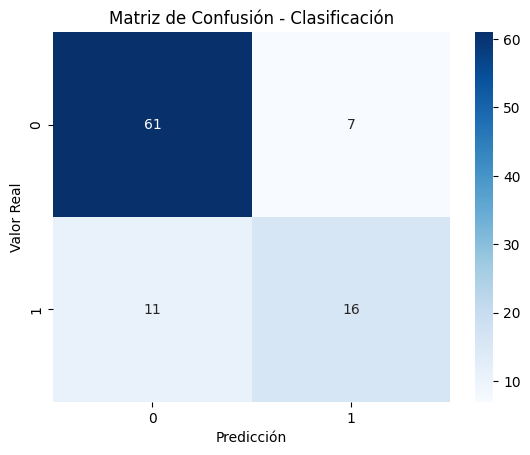

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Asegurarnos de que los valores sean enteros (True se convierte en 1, False en 0)
# Usamos map/replace por si Pandas lo leyó como texto ('True'/'False') o como booleano puro
datos['alerta'] = datos['alerta'].map({'True': 1, 'False': 0, True: 1, False: 0})
# 2. Definir nuevamente y_clf
y_clf = datos['alerta']

# 3. Volver a dividir los datos
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_scaled, y_clf, test_size=0.2, random_state=42)

# 4. Entrenar el modelo (¡Esto ya no debería dar error!)
clf_model = LogisticRegression()
clf_model.fit(X_train_c, y_train_c)

# 5. Predicciones
y_pred_c = clf_model.predict(X_test_c)
# Evaluación
print("--- Resultados de Clasificación ---")
print(f"Accuracy: {accuracy_score(y_test_c, y_pred_c):.2f}")
print("Reporte de Clasificación:")
print(classification_report(y_test_c, y_pred_c))

# Matriz de Confusión
cm = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Clasificación')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

- Algoritmo Regresión Logística

--- Resultados de Regresión ---
RMSE (Error Cuadrático Medio de la Raíz): 26.96
MAE (Error Absoluto Medio): 20.61
R2-score (Coeficiente de Determinación): 0.80


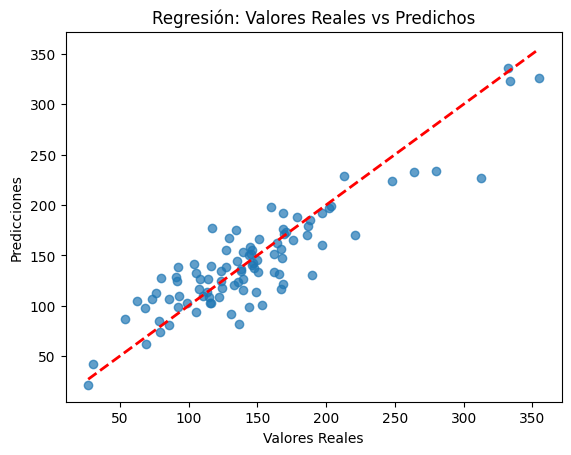

In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Definir variable objetivo para regresión
y_reg = datos['contaminacion']

# Dividir en entrenamiento y prueba
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_scaled, y_reg, test_size=0.2, random_state=42)

# Entrenar el modelo
reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)

# Predicciones
y_pred_r = reg_model.predict(X_test_r)

# Evaluación
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
mae = mean_absolute_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print("--- Resultados de Regresión ---")
print(f"RMSE (Error Cuadrático Medio de la Raíz): {rmse:.2f}")
print(f"MAE (Error Absoluto Medio): {mae:.2f}")
print(f"R2-score (Coeficiente de Determinación): {r2:.2f}")

# Gráfico de dispersión: Reales vs Predichos
plt.scatter(y_test_r, y_pred_r, alpha=0.7)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], '--r', linewidth=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Regresión: Valores Reales vs Predichos')
plt.show()